# Lipidomics Analysis Tutorial (Generalized for BODM-style Excel Files)

This notebook teaches you how to analyze lipidomics data from one or more Excel files (for example, `BODMFeb2025_Lipid.xlsx`).

You will learn how to:
1. Load and validate your data safely.
2. Clean sample columns and prepare a numeric matrix.
3. Run PCA to explore global sample patterns.
4. Run week-wise volcano analysis (microglia vs control).
5. Visualize fold-change patterns by lipid class.

The code is written to be readable and modifiable by students. Each section explains **what** is happening and **why** it matters.

## Input Contract (Required Columns)

Your input Excel file(s) must contain at least these two columns:
- `LipiID`: lipid identifier used for labels and result tables.
- `class`: lipid class used for class-based summaries and plots.

Important notes:
- This notebook **does not** infer lipid classes from names and does not strip lipid names.
- Any taxonomy parsing logic that creates new class/name columns has been intentionally excluded.
- Sample columns are detected by name patterns (configurable below).

In [3]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

# ------------------------------
# Configuration (edit this cell only)
# ------------------------------
CONFIG = {
    "input_files": [
        "BODMFeb2025_Lipid.xlsx",
        "BODMMarch2025_L.xlsx",
    ],
    "required_columns": ["LipiID", "class"],
    "column_aliases": {
        "LipiID": ["LipiID", "LipidID", "lipidid", "lipiid"],
        "class": ["class", "Class", "lipid_class", "LipidClass"],
    },
    "drop_if_name_contains": ["QC"],
    "replace_np_with_zero": True,
    "sample_column_prefix": "BODM",
    "condition_patterns": {
        "control": "control",
        "treated": "microglia",
    },
    "week_patterns": ["W5", "W7", "W9"],
    "volcano": {
        "log2fc_threshold": 1.0,
        "p_threshold": 0.05,
    },
    "pca": {
        "kmeans_clusters": 6,
        "random_state": 42,
    },
    "output_dir": "tutorial_outputs",
}

output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)

print("Configured input files:")
for f in CONFIG["input_files"]:
    print(" -", f)
print("Output directory:", output_dir.resolve())

Configured input files:
 - BODMFeb2025_Lipid.xlsx
 - BODMMarch2025_L.xlsx
Output directory: /Users/bbbartel/Workspaces/Lipidomics/tutorial_outputs


## Step 1: Load, Validate, and Inspect Data

In this step we:
1. Read each Excel file listed in `CONFIG["input_files"]`.
2. Check for required columns (`LipiID`, `class`).
3. Remove QC columns and convert sample values to numeric.
4. Build a clean dataset dictionary for downstream analysis.

Why this matters:
- Most analysis errors come from input mismatches.
- Failing early with clear messages is better than silently producing wrong statistics.

In [8]:
def find_sample_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    return [c for c in df.columns if str(c).startswith(prefix)]


def detect_week_from_col(col_name: str, week_patterns: list[str]) -> str:
    for week in week_patterns:
        if week in str(col_name):
            return week
    return "Unassigned"


def split_condition_columns(cols: list[str], condition_patterns: dict) -> tuple[list[str], list[str]]:
    control_pattern = condition_patterns["control"].lower()
    treated_pattern = condition_patterns["treated"].lower()

    control_cols = [c for c in cols if control_pattern in str(c).lower()]
    treated_cols = [c for c in cols if treated_pattern in str(c).lower()]
    return control_cols, treated_cols


def normalize_required_columns(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    # Rename known aliases to canonical names so downstream code stays simple.
    alias_map = config.get("column_aliases", {})
    rename_map = {}

    for canonical in config["required_columns"]:
        if canonical in df.columns:
            continue

        candidates = alias_map.get(canonical, [])
        match = next((c for c in candidates if c in df.columns), None)
        if match is not None:
            rename_map[match] = canonical

    if rename_map:
        df = df.rename(columns=rename_map)

    missing_required = [c for c in config["required_columns"] if c not in df.columns]
    if missing_required:
        raise ValueError(
            f"Required columns missing after alias normalization: {missing_required}. "
            f"Found columns include: {list(df.columns[:20])}"
        )

    return df


def load_and_prepare_excel(file_path: Path, config: dict) -> pd.DataFrame:
    if not file_path.exists():
        raise FileNotFoundError(f"Input file not found: {file_path}")

    df = pd.read_excel(file_path)
    df = normalize_required_columns(df, config)

    drop_patterns = config.get("drop_if_name_contains", [])
    cols_to_drop = [c for c in df.columns if any(p in str(c) for p in drop_patterns)]
    df = df.drop(columns=cols_to_drop, errors="ignore")

    sample_cols = find_sample_columns(df, config["sample_column_prefix"])
    if not sample_cols:
        raise ValueError(
            f"No sample columns found in '{file_path.name}'. "
            f"Expected columns starting with '{config['sample_column_prefix']}'."
        )

    if config.get("replace_np_with_zero", True):
        df[sample_cols] = df[sample_cols].mask(df[sample_cols] == "NP", 0)

    df[sample_cols] = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    return df


# Load all configured files
all_datasets: dict[str, pd.DataFrame] = {}
for path_str in CONFIG["input_files"]:
    path = Path(path_str)
    dataset_key = path.stem
    all_datasets[dataset_key] = load_and_prepare_excel(path, CONFIG)


# Tutorial checkpoint: summarize what was detected
summary_rows = []
for name, df in all_datasets.items():
    sample_cols = find_sample_columns(df, CONFIG["sample_column_prefix"])
    control_cols, treated_cols = split_condition_columns(sample_cols, CONFIG["condition_patterns"])
    week_counts = pd.Series([detect_week_from_col(c, CONFIG["week_patterns"]) for c in sample_cols]).value_counts().to_dict()

    summary_rows.append(
        {
            "dataset": name,
            "rows_lipids": df.shape[0],
            "total_columns": df.shape[1],
            "sample_columns": len(sample_cols),
            "control_columns": len(control_cols),
            "treated_columns": len(treated_cols),
            "weeks_detected": week_counts,
        }
    )

summary_df = pd.DataFrame(summary_rows)
print("Data loading summary:")
display(summary_df)

# Show first rows of the first dataset so students can verify columns
first_key = next(iter(all_datasets))
print(f"\nPreview of dataset: {first_key}")
display(all_datasets[first_key].head())

Data loading summary:


,dataset,rows_lipids,total_columns,sample_columns,control_columns,treated_columns,weeks_detected
0,BODMFeb2025_Lipid,2781,25,18,9,9,"{'W5': 6, 'W7': 6, 'W9': 6}"
1,BODMMarch2025_L,2781,20,13,7,6,"{'W5': 5, 'W7': 4, 'W9': 4}"



Preview of dataset: BODMFeb2025_Lipid


,LipiID,LipidGroup,CalcMz,BaseRt,class,Polarity,IonFormula,BODMFeb_microglia_W5_1_lipid,BODMFeb_microglia_W5_2_lipid,BODMFeb_microglia_W5_3_lipid,...,BODMFeb_microglia_W7_3_lipid,BODMFeb_control_W7_1_lipid,BODMFeb_control_W7_2_lipid,BODMFeb_control_W7_3_lipid,BODMFeb_microglia_W9_1_lipid,BODMFeb_microglia_W9_2_lipid,BODMFeb_microglia_W9_3_lipid,BODMFeb_control_W9_1_lipid,BODMFeb_control_W9_2_lipid,BODMFeb_control_W9_3_lipid
0,MGDG(22:4_11:1),MGDG(33:5),733.4896,5.966510,MGDG,Neg,C42 H69 O10,345.5753,96.75897,585.3891,...,202.7141,583.2162,177.6537,70719.36,463.8379,603.6548,421.9771,216.9963,362.3832,32.84123
1,PI(O,PI(O,871.5695,7.417510,PI,Pos,C47 H84 O12 P1,8573.8140,2527.07700,7684.6260,...,8055.0700,8498.2700,8302.2920,350607.60,8571.6700,7327.9610,6725.8390,7469.8850,8256.9260,9938.91300
2,SM(d42:1),SM(d42:1),815.7001,7.266004,SM,Pos,C47 H96 N2 O6 P1,60057.8200,53282.94000,61215.0800,...,14416.6000,14286.1900,25199.5900,19177.99,18597.6200,40392.8900,52816.0700,35509.3000,23613.5700,41041.77000
3,PC(O,PC(O,1002.7530,8.293578,PC,Neg,C59 H105 N1 O9 P1,35605.2800,53061.53000,35008.4400,...,26207.3900,12825.8900,10257.8700,11415.41,3285.3410,11186.0500,8335.9360,4543.2660,12125.6400,10516.47000
4,PC(O,PC(O,1002.7530,8.293578,PC,Neg,C59 H105 N1 O9 P1,35605.2800,53061.53000,35008.4400,...,26207.3900,12825.8900,10257.8700,11415.41,3285.3410,11186.0500,8335.9360,4543.2660,12125.6400,10516.47000


## Step 2: PCA and Clustering

PCA reduces thousands of lipid features into a few summary axes (principal components).

Why students use this:
- To see whether samples naturally separate by week or condition.
- To detect outliers before running per-lipid statistics.

We also run K-means on the first two PCs as an exploratory grouping tool.


Running PCA for: BODMFeb2025_Lipid


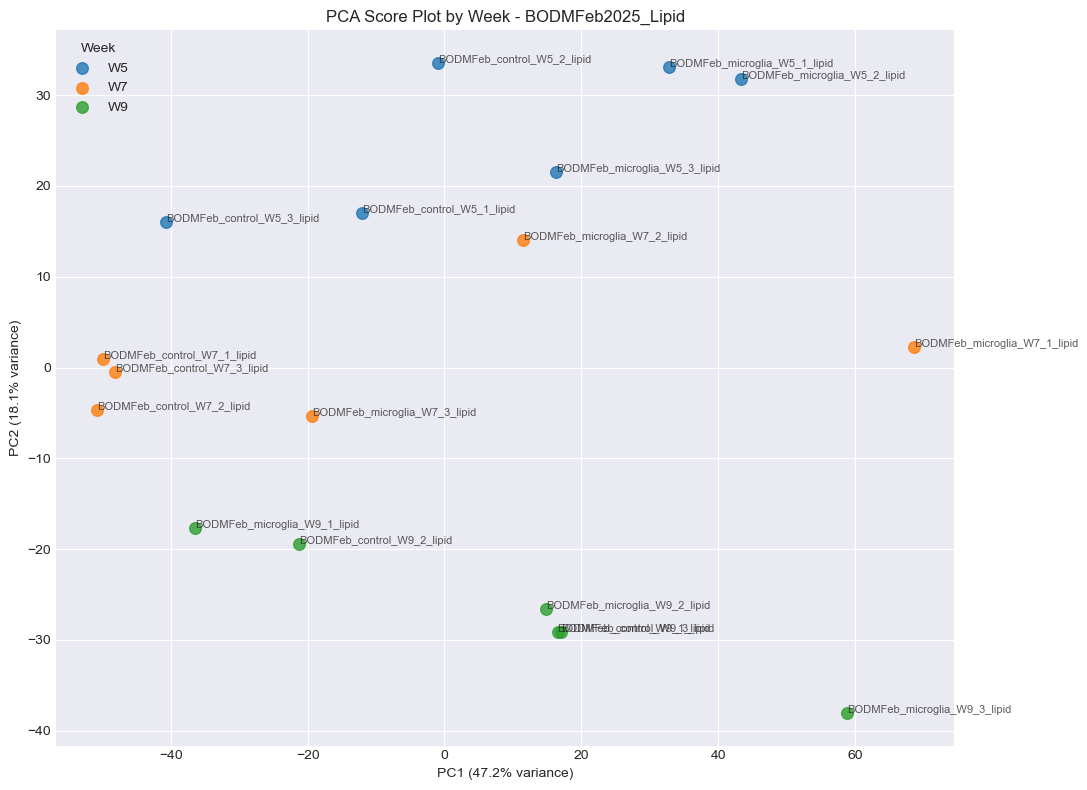

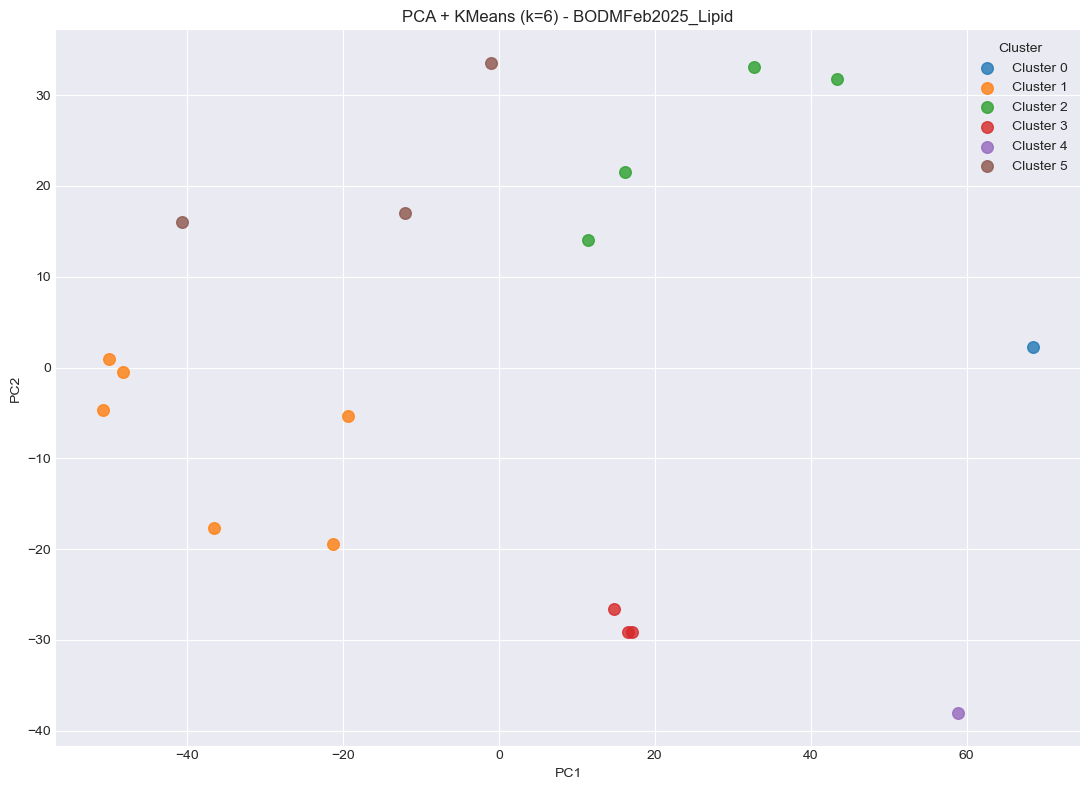

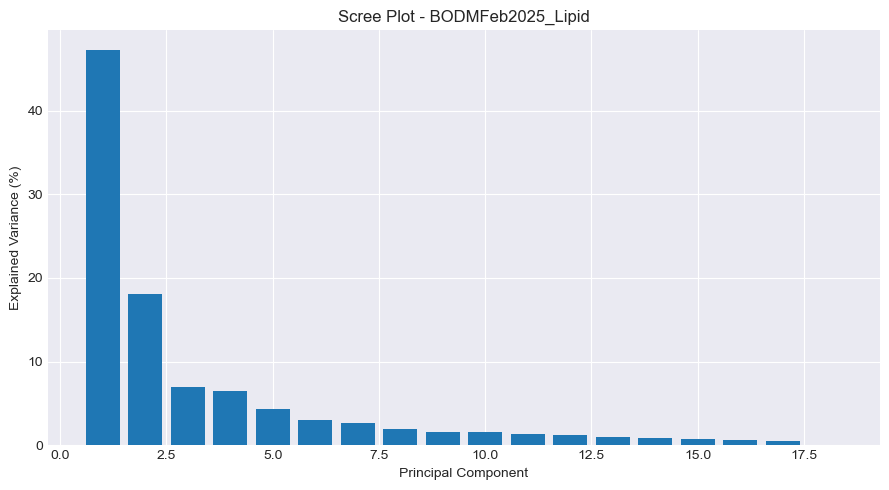

BODMFeb2025_Lipid: cumulative variance explained by first 2 PCs = 65.28%

Running PCA for: BODMMarch2025_L


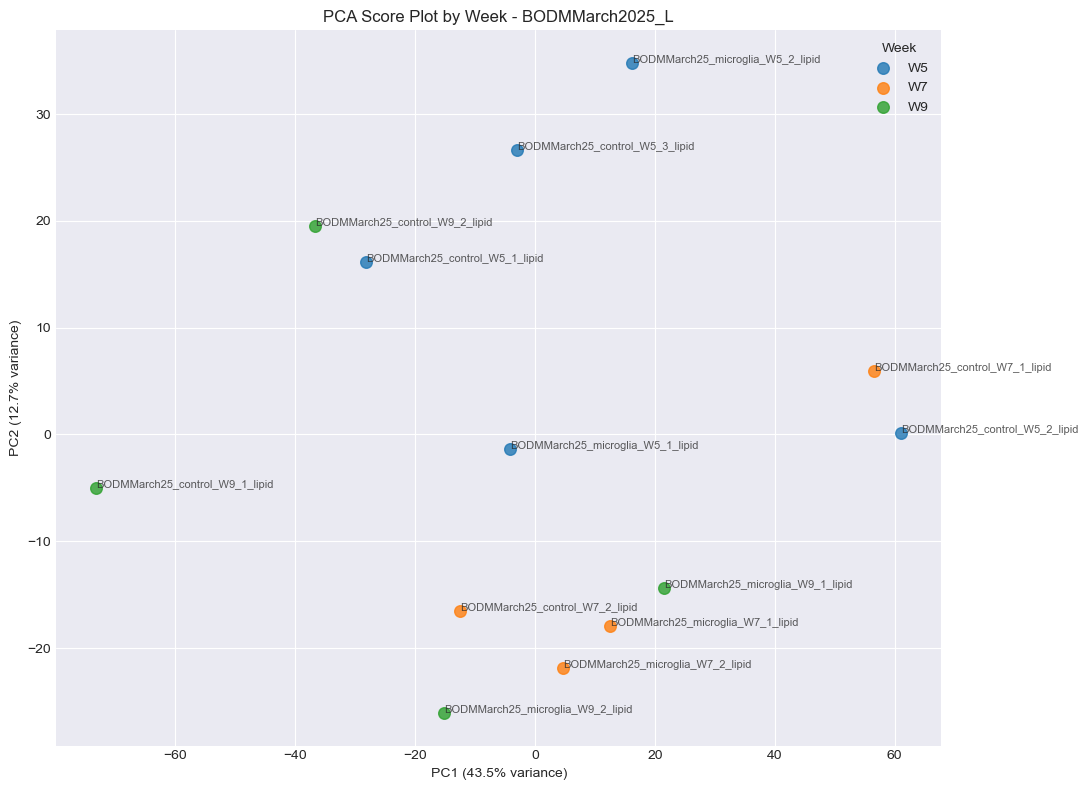

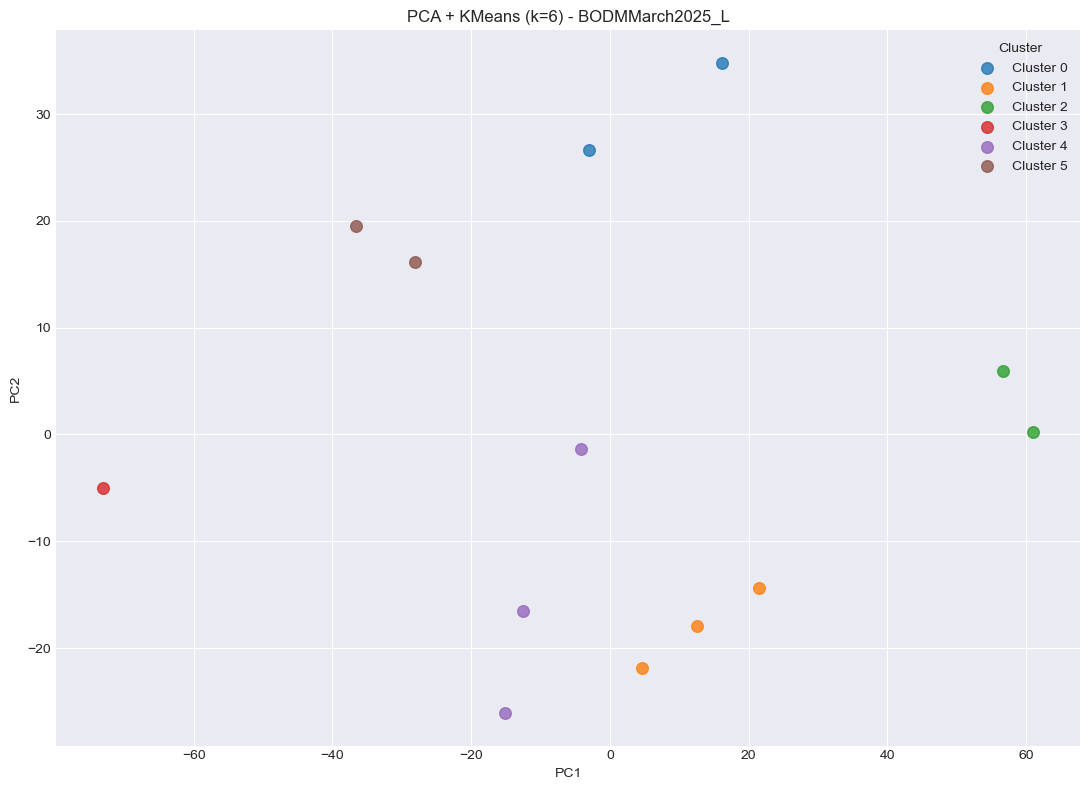

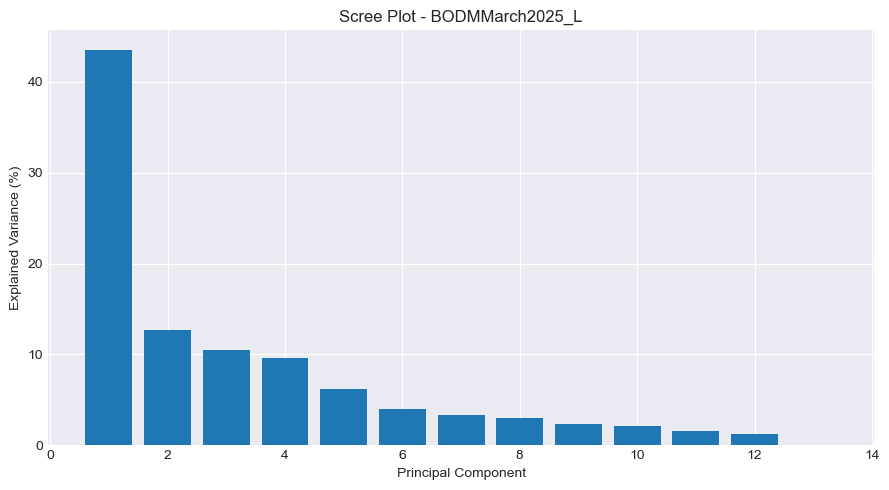

BODMMarch2025_L: cumulative variance explained by first 2 PCs = 56.18%


In [5]:
# ------------------------------
# Step 2: PCA (Principal Component Analysis)
# ------------------------------
# PCA helps us see global structure in high-dimensional lipid data.
# We transpose because PCA expects rows=samples and columns=features.


def run_pca_for_dataset(df: pd.DataFrame, dataset_name: str, config: dict):
    sample_cols = find_sample_columns(df, config["sample_column_prefix"])
    X = df[sample_cols].T

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA()
    scores = pca.fit_transform(X_scaled)

    labels = X.index.tolist()
    weeks = [detect_week_from_col(col, config["week_patterns"]) for col in labels]

    k = config["pca"]["kmeans_clusters"]
    kmeans = KMeans(n_clusters=k, random_state=config["pca"]["random_state"], n_init="auto")
    clusters = kmeans.fit_predict(scores[:, :2])

    pca_df = pd.DataFrame(
        {
            "sample": labels,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "week": weeks,
            "cluster": clusters,
        }
    )

    # Plot 1: PCA scatter by week
    fig, ax = plt.subplots(figsize=(11, 8))
    for wk, sub in pca_df.groupby("week"):
        ax.scatter(sub["PC1"], sub["PC2"], label=wk, alpha=0.8, s=70)

    for _, row in pca_df.iterrows():
        ax.annotate(row["sample"], (row["PC1"], row["PC2"]), fontsize=8, alpha=0.75)

    ax.set_title(f"PCA Score Plot by Week - {dataset_name}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
    ax.legend(title="Week")
    plt.tight_layout()
    plt.show()

    # Plot 2: PCA scatter by cluster
    fig, ax = plt.subplots(figsize=(11, 8))
    for cl, sub in pca_df.groupby("cluster"):
        ax.scatter(sub["PC1"], sub["PC2"], label=f"Cluster {cl}", alpha=0.8, s=70)

    ax.set_title(f"PCA + KMeans (k={k}) - {dataset_name}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # Plot 3: Scree plot
    fig, ax = plt.subplots(figsize=(9, 5))
    explained = pca.explained_variance_ratio_ * 100
    ax.bar(range(1, len(explained) + 1), explained)
    ax.set_title(f"Scree Plot - {dataset_name}")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance (%)")
    plt.tight_layout()
    plt.show()

    print(f"{dataset_name}: cumulative variance explained by first 2 PCs = {explained[:2].sum():.2f}%")


for ds_name, ds_df in all_datasets.items():
    print("\n" + "=" * 80)
    print(f"Running PCA for: {ds_name}")
    run_pca_for_dataset(ds_df, ds_name, CONFIG)

## Step 3: Volcano Analysis by Week (Microglia vs Control)

A volcano plot combines:
- **Effect size**: log2 fold change (how large the change is).
- **Statistical evidence**: p-value from a two-sample t-test.

Interpretation reminder:
- Positive log2FC means higher in microglia.
- Negative log2FC means lower in microglia.
- We use configurable thresholds for significance and fold-change.

This section runs week-by-week for each dataset and exports result tables.

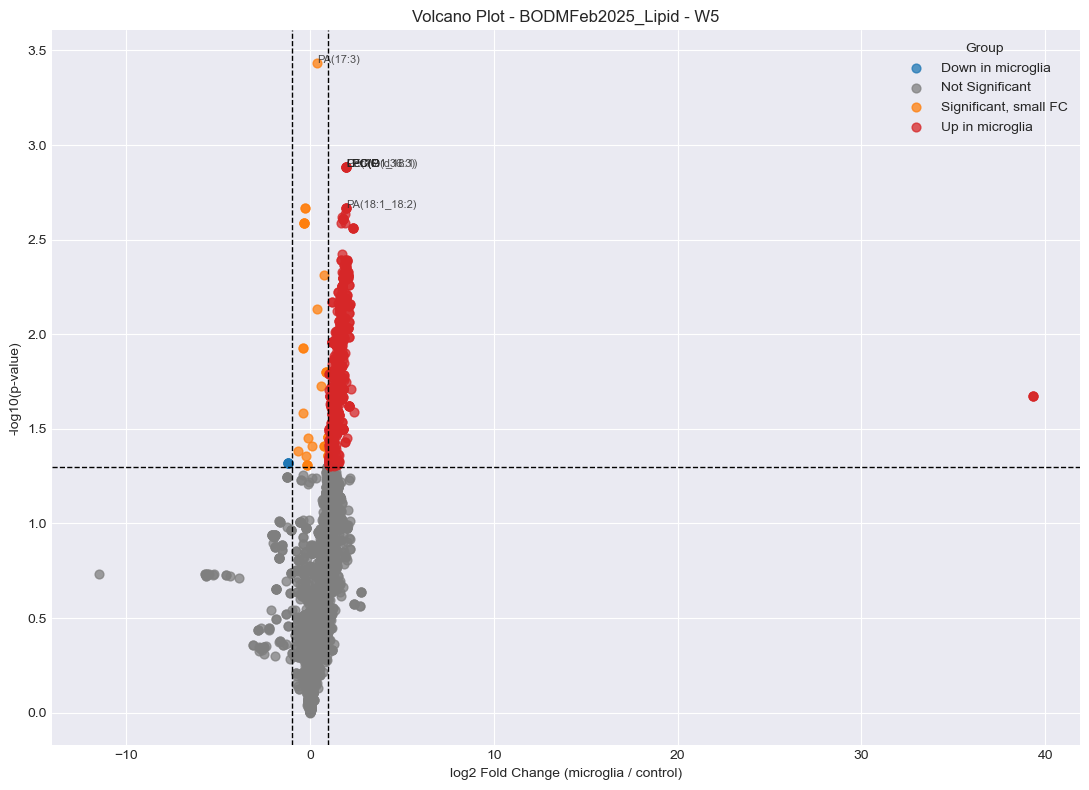

Saved volcano table: tutorial_outputs/BODMFeb2025_Lipid_volcano_W5.csv


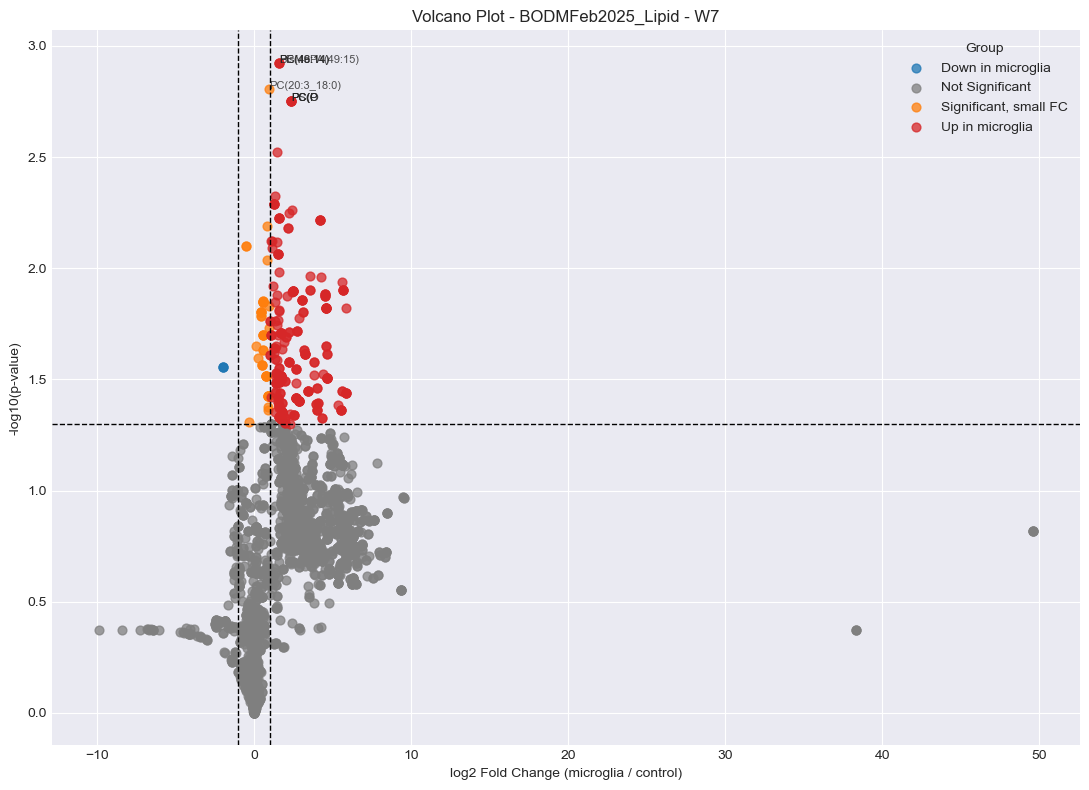

Saved volcano table: tutorial_outputs/BODMFeb2025_Lipid_volcano_W7.csv


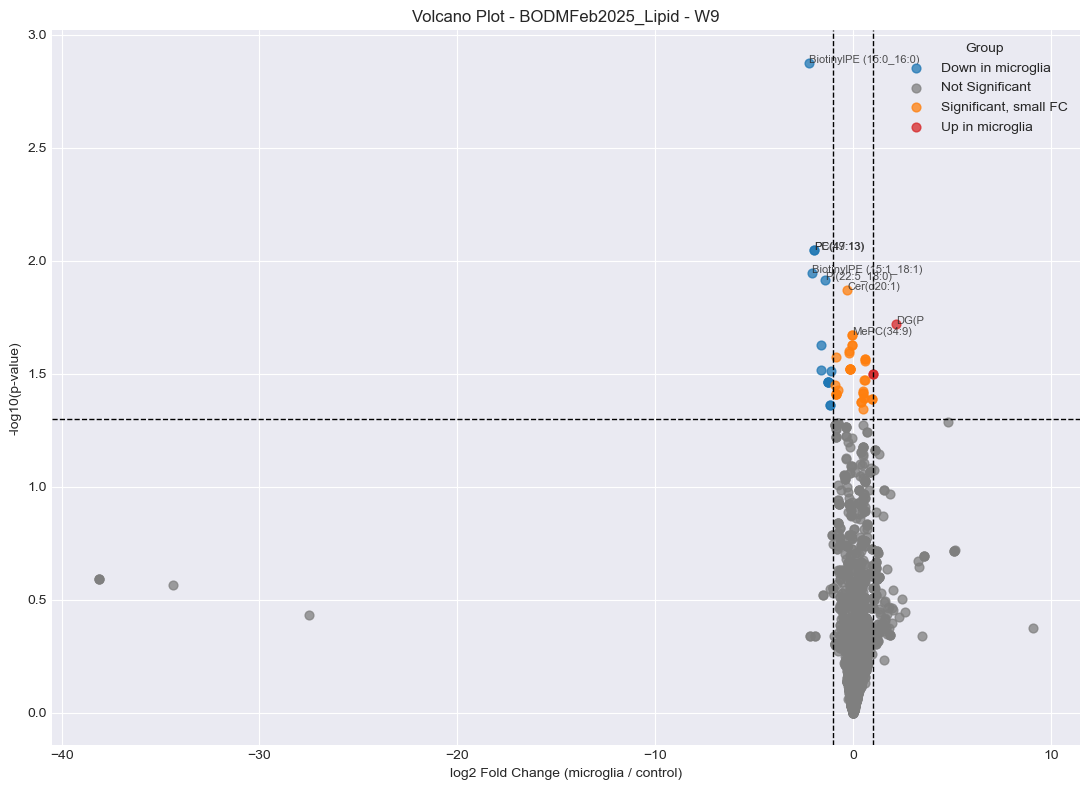

Saved volcano table: tutorial_outputs/BODMFeb2025_Lipid_volcano_W9.csv


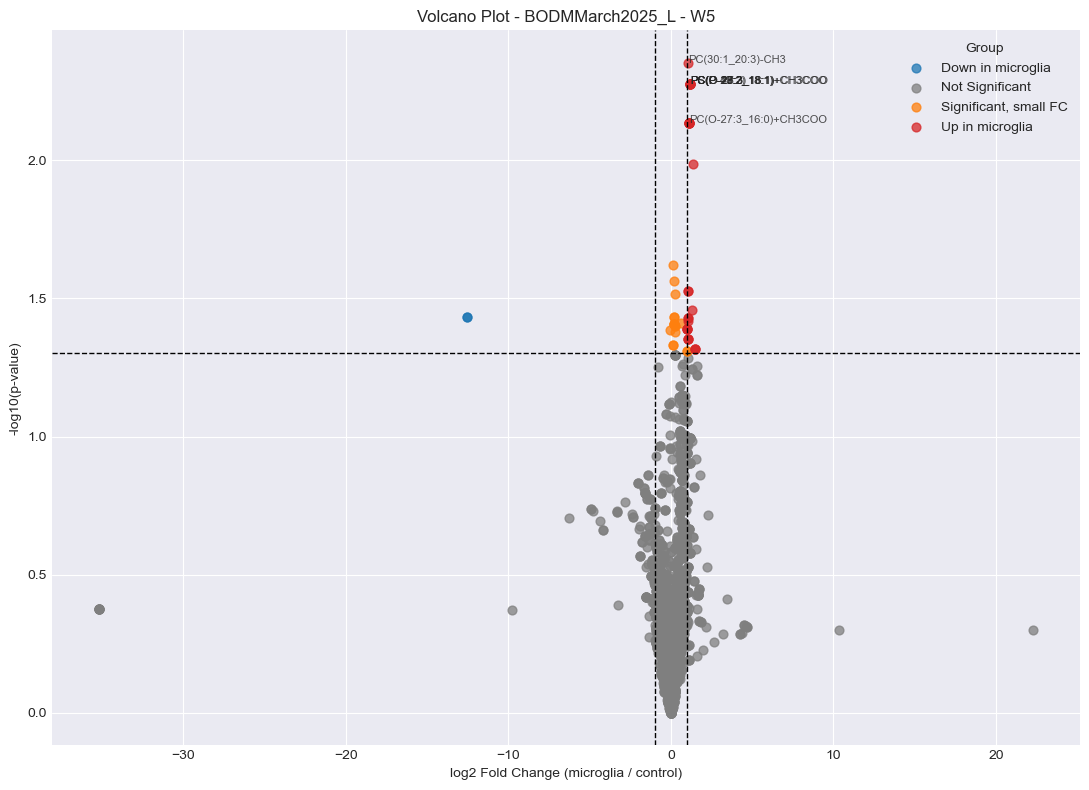

Saved volcano table: tutorial_outputs/BODMMarch2025_L_volcano_W5.csv


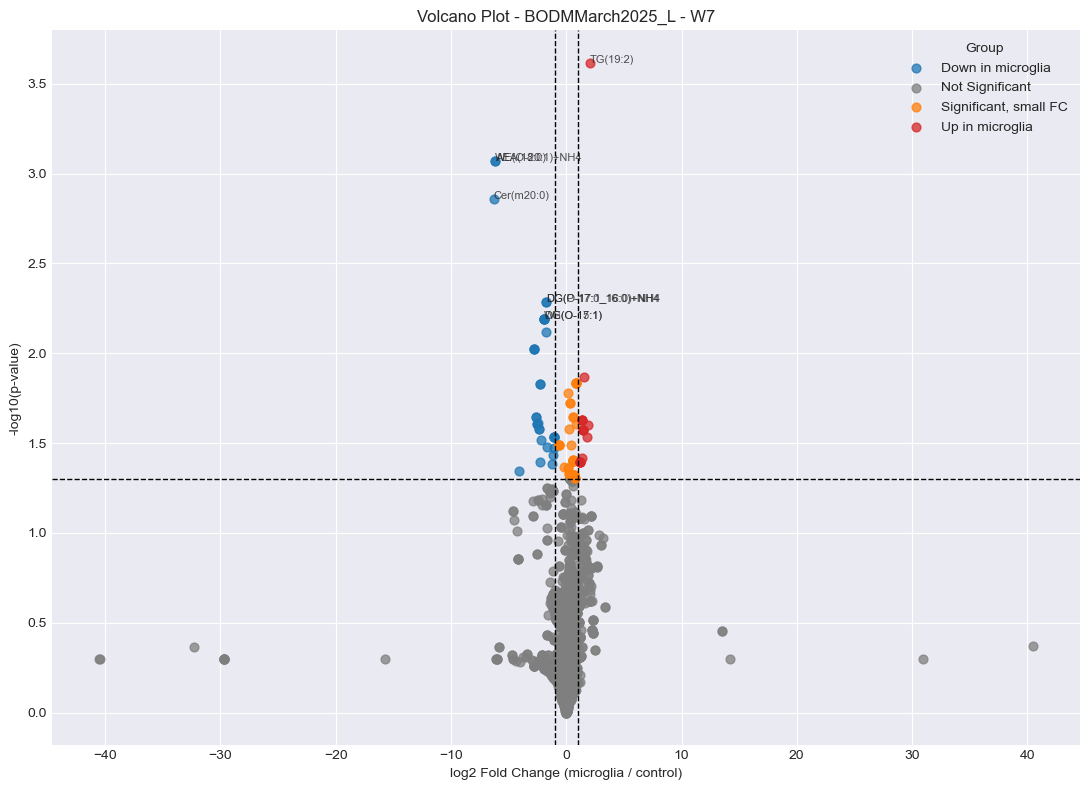

Saved volcano table: tutorial_outputs/BODMMarch2025_L_volcano_W7.csv


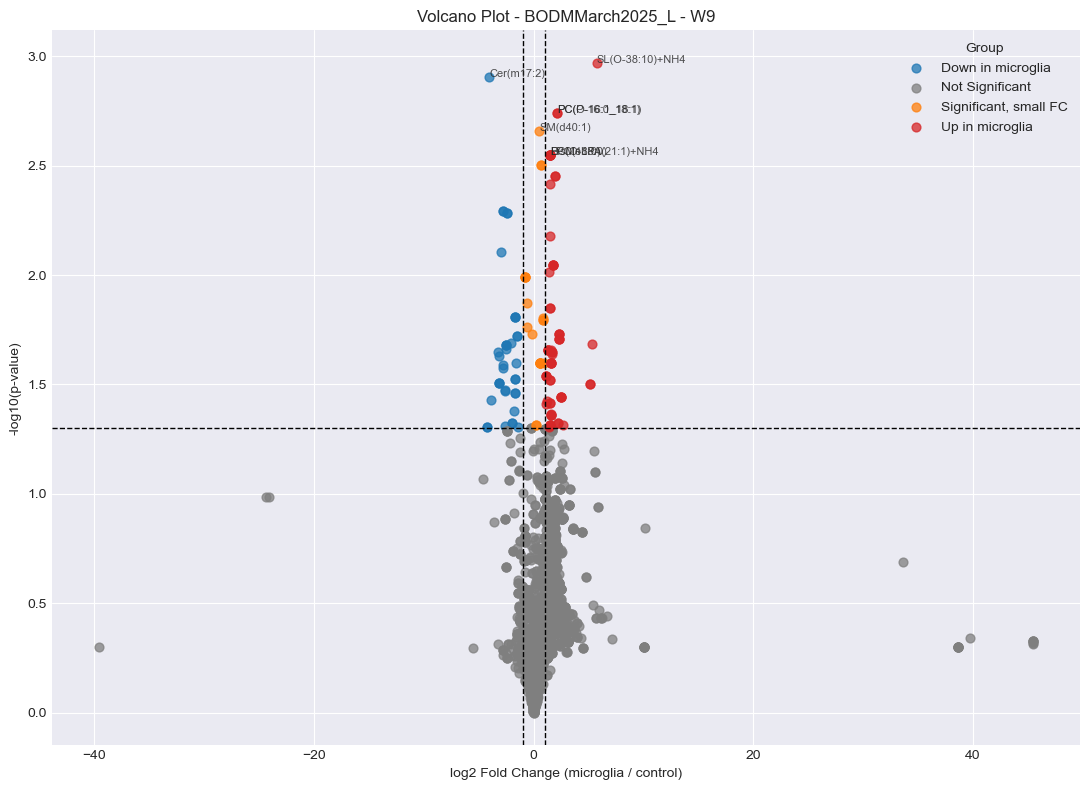

Saved volcano table: tutorial_outputs/BODMMarch2025_L_volcano_W9.csv


In [6]:
# ------------------------------
# Step 3 code: Volcano analysis
# ------------------------------

def compute_weekly_volcano(df: pd.DataFrame, dataset_name: str, week_label: str, config: dict) -> pd.DataFrame:
    sample_cols = find_sample_columns(df, config["sample_column_prefix"])
    week_cols = [c for c in sample_cols if week_label in str(c)]
    if not week_cols:
        print(f"[{dataset_name}] No columns found for week {week_label}. Skipping.")
        return pd.DataFrame()

    control_cols, treated_cols = split_condition_columns(week_cols, config["condition_patterns"])
    if not control_cols or not treated_cols:
        print(
            f"[{dataset_name}] Week {week_label}: missing control or treated columns. "
            f"control={len(control_cols)}, treated={len(treated_cols)}. Skipping."
        )
        return pd.DataFrame()

    epsilon = 1e-10
    records = []

    for _, row in df.iterrows():
        control_vals = row[control_cols].astype(float).values
        treated_vals = row[treated_cols].astype(float).values

        control_mean = float(np.mean(control_vals))
        treated_mean = float(np.mean(treated_vals))
        log2_fc = np.log2((treated_mean + epsilon) / (control_mean + epsilon))

        _, p_val = ttest_ind(treated_vals, control_vals, equal_var=False, nan_policy="omit")
        if np.isnan(p_val):
            p_val = 1.0

        records.append(
            {
                "LipiID": row["LipiID"],
                "class": row["class"],
                "log2FC": log2_fc,
                "p_value": p_val,
                "mean_control": control_mean,
                "mean_treated": treated_mean,
            }
        )

    res = pd.DataFrame(records)
    res["neg_log10_p"] = -np.log10(res["p_value"].clip(lower=1e-300))

    fc_thr = config["volcano"]["log2fc_threshold"]
    p_thr = config["volcano"]["p_threshold"]

    res["volcano_group"] = "Not Significant"
    res.loc[(res["p_value"] < p_thr) & (res["log2FC"] >= fc_thr), "volcano_group"] = "Up in microglia"
    res.loc[(res["p_value"] < p_thr) & (res["log2FC"] <= -fc_thr), "volcano_group"] = "Down in microglia"
    res.loc[(res["p_value"] < p_thr) & (res["log2FC"].abs() < fc_thr), "volcano_group"] = "Significant, small FC"

    return res


def plot_volcano(res: pd.DataFrame, dataset_name: str, week_label: str, config: dict) -> None:
    if res.empty:
        return

    fc_thr = config["volcano"]["log2fc_threshold"]
    p_thr = config["volcano"]["p_threshold"]
    y_thr = -np.log10(p_thr)

    color_map = {
        "Up in microglia": "#d62728",
        "Down in microglia": "#1f77b4",
        "Significant, small FC": "#ff7f0e",
        "Not Significant": "#7f7f7f",
    }

    fig, ax = plt.subplots(figsize=(11, 8))
    for grp, sub in res.groupby("volcano_group"):
        ax.scatter(
            sub["log2FC"],
            sub["neg_log10_p"],
            label=grp,
            alpha=0.75,
            s=40,
            color=color_map.get(grp, "#7f7f7f"),
        )

    ax.axvline(fc_thr, linestyle="--", color="black", linewidth=1)
    ax.axvline(-fc_thr, linestyle="--", color="black", linewidth=1)
    ax.axhline(y_thr, linestyle="--", color="black", linewidth=1)

    top = res.nsmallest(8, "p_value")
    for _, row in top.iterrows():
        ax.annotate(str(row["LipiID"]), (row["log2FC"], row["neg_log10_p"]), fontsize=8, alpha=0.8)

    ax.set_title(f"Volcano Plot - {dataset_name} - {week_label}")
    ax.set_xlabel("log2 Fold Change (microglia / control)")
    ax.set_ylabel("-log10(p-value)")
    ax.legend(title="Group", loc="upper right")
    plt.tight_layout()
    plt.show()


all_volcano_results: dict[str, dict[str, pd.DataFrame]] = {}

for ds_name, ds_df in all_datasets.items():
    all_volcano_results[ds_name] = {}
    for wk in CONFIG["week_patterns"]:
        res = compute_weekly_volcano(ds_df, ds_name, wk, CONFIG)
        all_volcano_results[ds_name][wk] = res

        if res.empty:
            continue

        plot_volcano(res, ds_name, wk, CONFIG)

        out_csv = output_dir / f"{ds_name}_volcano_{wk}.csv"
        res.to_csv(out_csv, index=False)
        print(f"Saved volcano table: {out_csv}")

## Step 4: Taxonomy-Class Visualization (Using Existing `class`)

Now we summarize fold-change behavior at the lipid class level.

Important design decisions:
- We use the existing `class` column from your input file.
- We do not create or infer new class columns by parsing lipid names.
- For plotting aesthetics only, we optionally parse `LipiID` to estimate:
  - `chain_length` (color/hue)
  - `chain_count` (filled vs empty circles)

This keeps class assignment faithful to your input while still enabling richer tutorial plots.

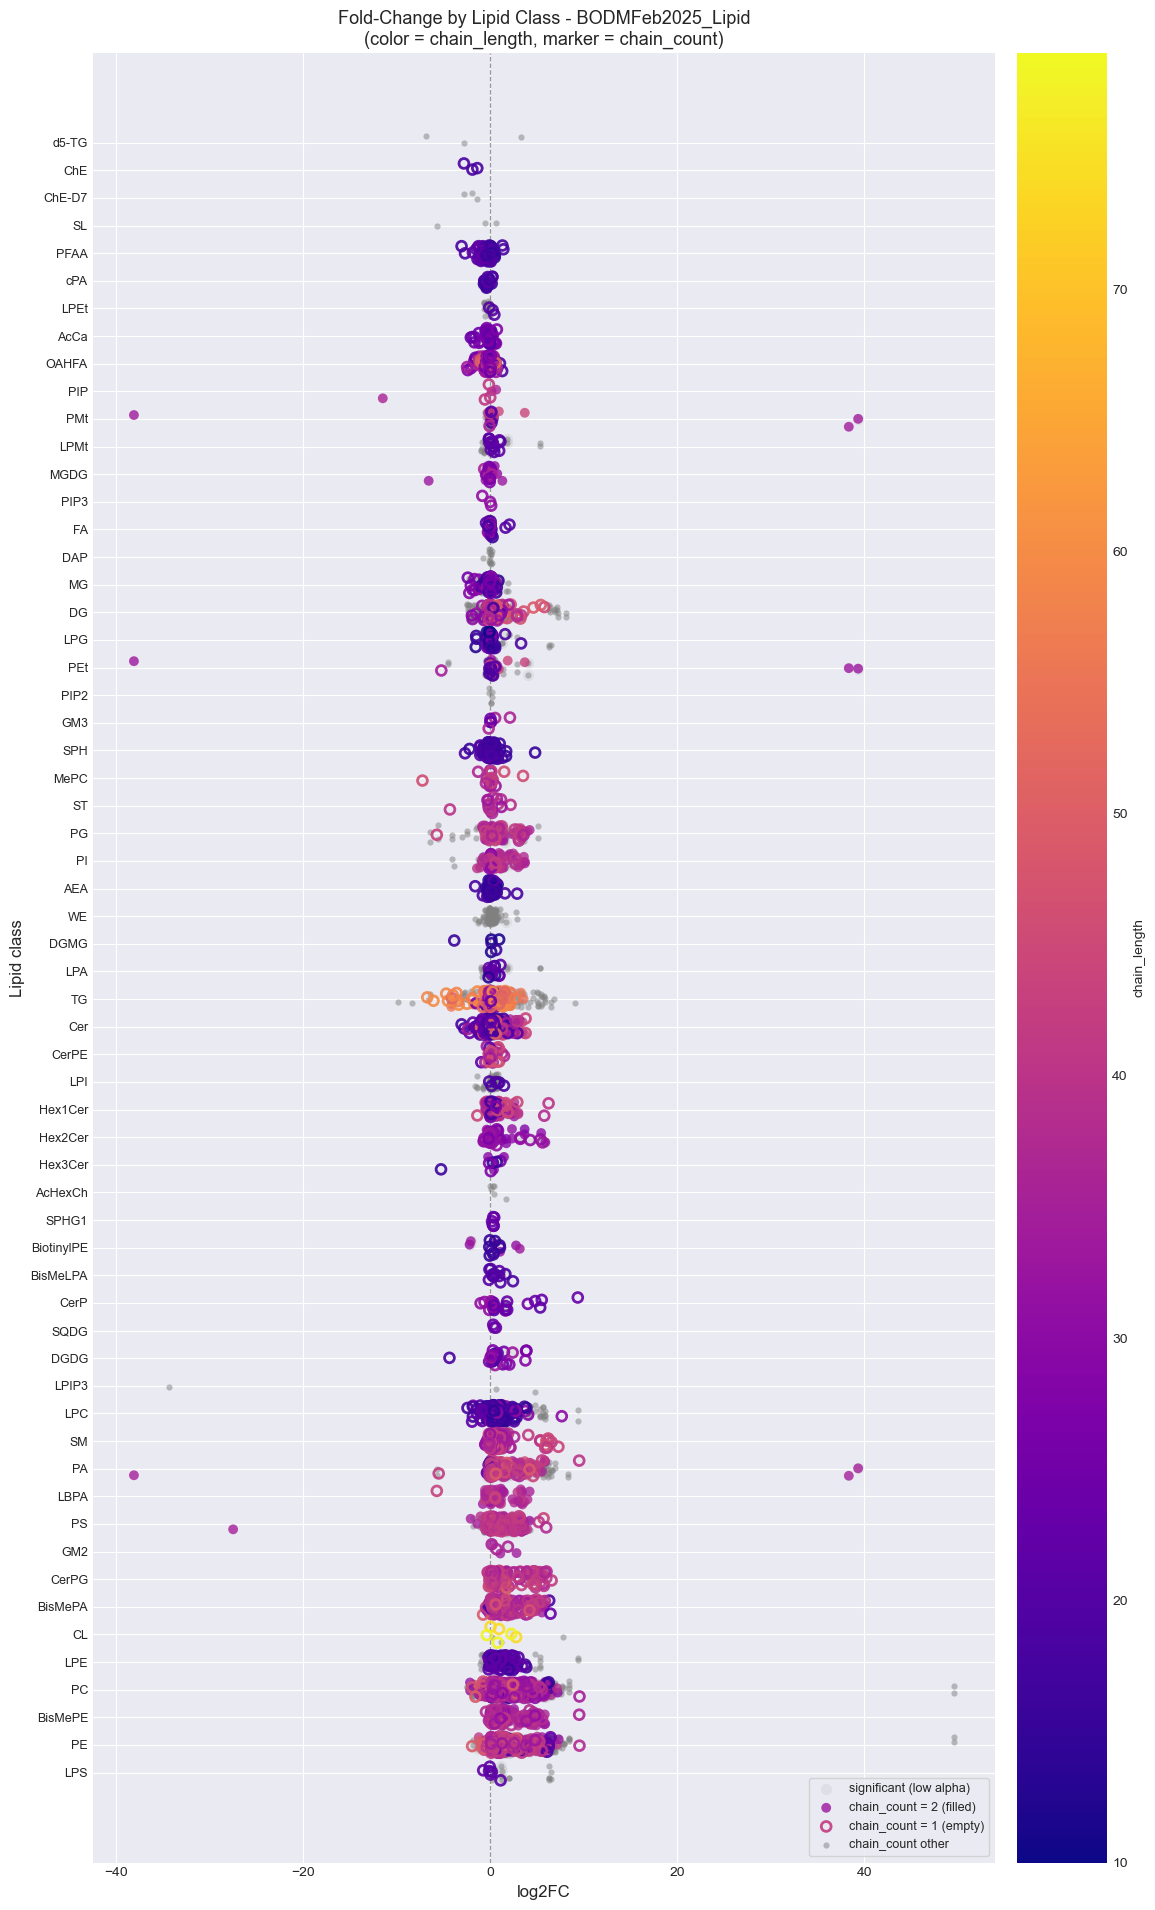

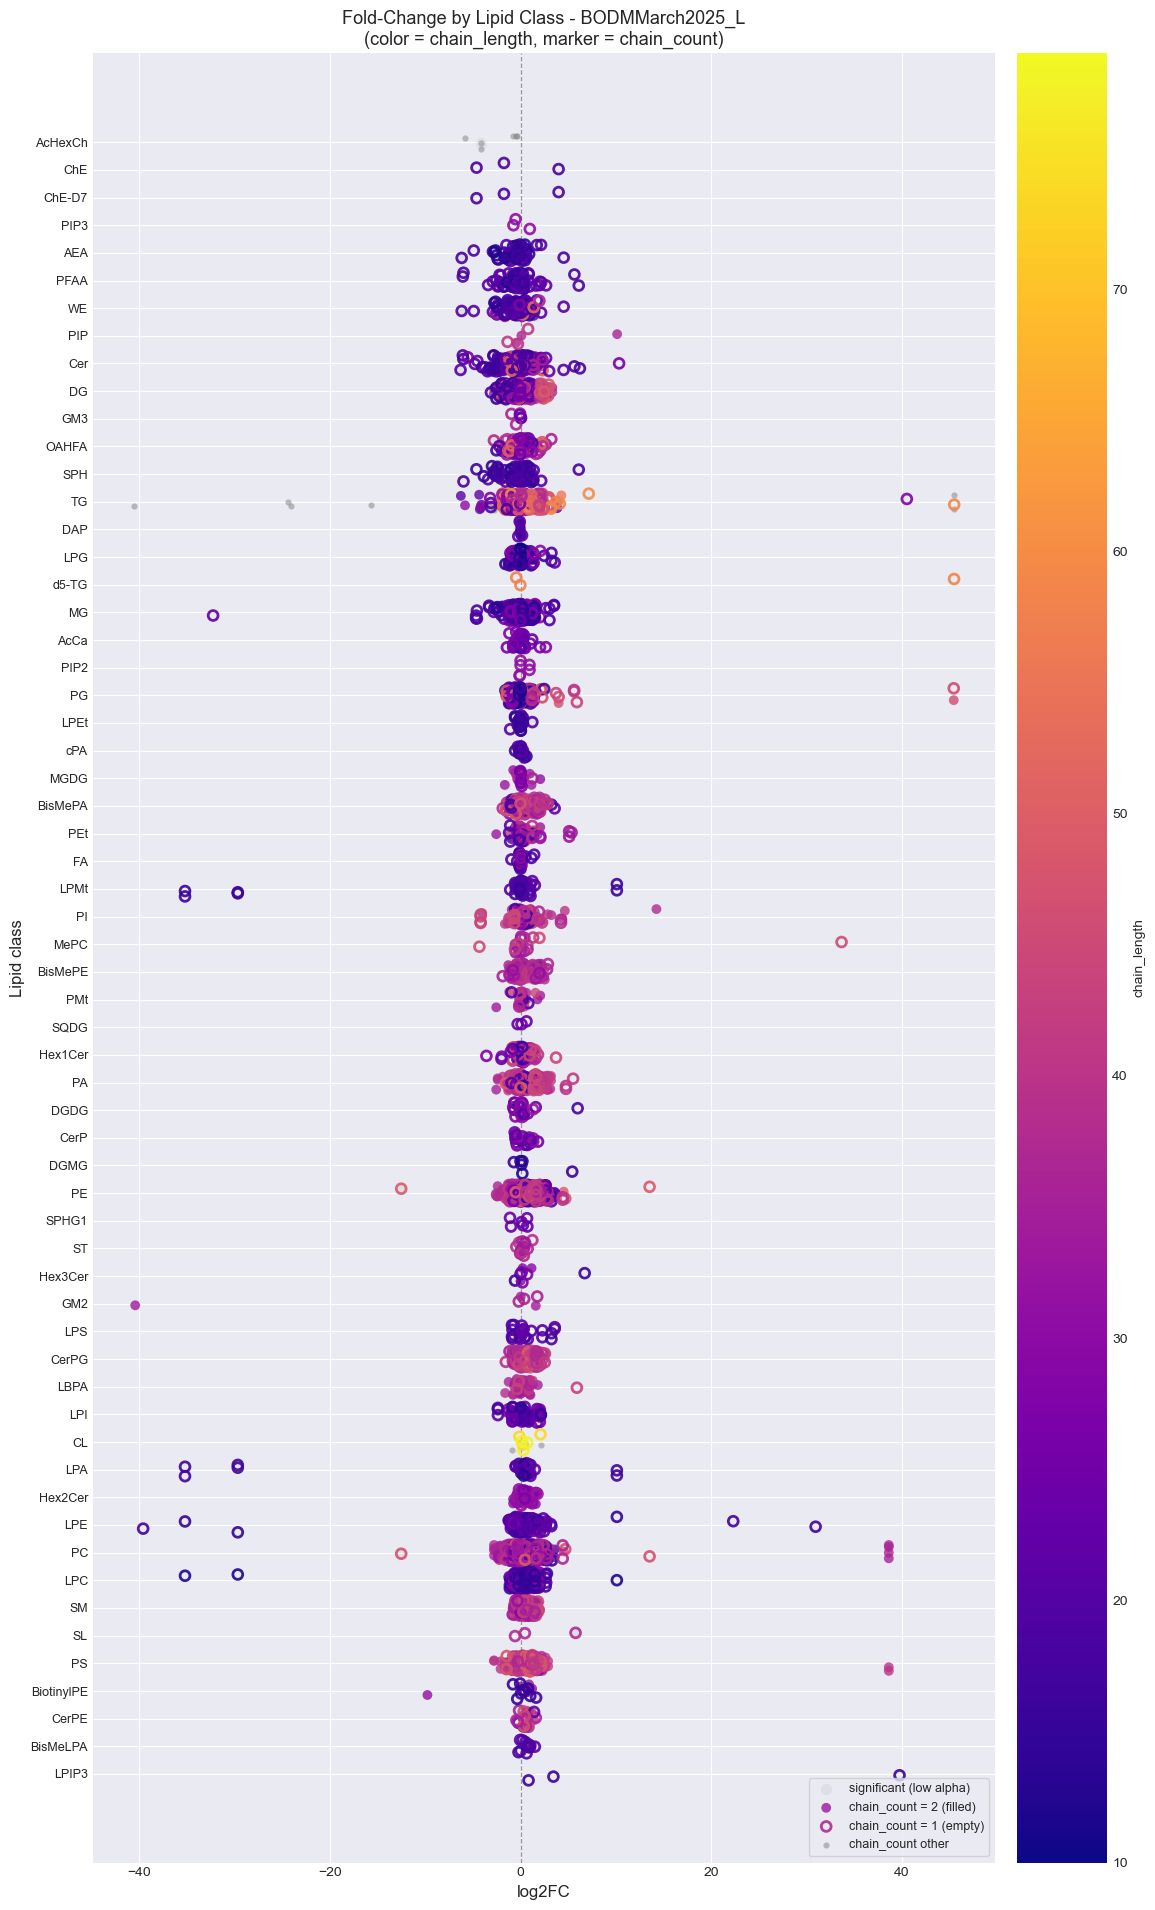

In [ ]:
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def extract_chain_tokens_from_lipiid(lipid_id: str) -> list[tuple[int, int]]:
    """Extract (carbons, double_bonds) tokens like 18:1 from LipiID."""
    if pd.isna(lipid_id):
        return []
    return [(int(a), int(b)) for a, b in re.findall(r"(\d+):(\d+)", str(lipid_id))]


def estimate_chain_length(lipid_id: str) -> float:
    tokens = extract_chain_tokens_from_lipiid(lipid_id)
    if not tokens:
        return np.nan
    return float(sum(carbons for carbons, _ in tokens))


def estimate_chain_count(lipid_id: str) -> float:
    tokens = extract_chain_tokens_from_lipiid(lipid_id)
    if not tokens:
        return np.nan
    return float(len(tokens))


def build_taxonomy_source(df: pd.DataFrame, volcano_dict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Prefer weekly volcano results because they already contain log2FC values.
    frames = []
    for wk, wk_df in volcano_dict.items():
        if wk_df.empty:
            continue
        tmp = wk_df.copy()
        tmp["week"] = wk
        frames.append(tmp)

    if frames:
        out = pd.concat(frames, ignore_index=True)
    else:
        # Fallback for externally precomputed fold-change columns (if present)
        out = pd.DataFrame()
        for candidate in ["log2FC", "log_fc", "fold_change", "fold_fc", "fold-fc"]:
            if candidate in df.columns:
                out = df[["LipiID", "class", candidate]].copy()
                out = out.rename(columns={candidate: "log2FC"})
                out["week"] = "all"
                break

    if out.empty:
        return out

    # Prefer existing chain columns if present; otherwise parse from LipiID.
    if "chain_length" in df.columns:
        chain_map = df[["LipiID", "chain_length"]].drop_duplicates(subset=["LipiID"])
        out = out.merge(chain_map, on="LipiID", how="left")
    else:
        out["chain_length"] = out["LipiID"].apply(estimate_chain_length)

    if "chain_count" in df.columns:
        count_map = df[["LipiID", "chain_count"]].drop_duplicates(subset=["LipiID"])
        out = out.merge(count_map, on="LipiID", how="left")
    else:
        out["chain_count"] = out["LipiID"].apply(estimate_chain_count)

    return out


def plot_class_fc_strip(tax_df: pd.DataFrame, dataset_name: str) -> None:
    if tax_df.empty:
        print(f"[{dataset_name}] No class-level fold-change source table available. Skipping class plot.")
        return

    required = {"class", "log2FC", "chain_length", "chain_count"}
    if not required.issubset(tax_df.columns):
        print(f"[{dataset_name}] Missing required columns for enhanced class plot: {required - set(tax_df.columns)}")
        return

    plot_df = tax_df.copy()
    plot_df = plot_df.dropna(subset=["class", "log2FC"]).copy()
    if plot_df.empty:
        print(f"[{dataset_name}] No rows left after filtering. Skipping class plot.")
        return

    # Order classes by median fold-change (descending) to match tutorial sample.
    class_order = (
        plot_df.groupby("class")["log2FC"]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    class_to_y = {cls: i for i, cls in enumerate(class_order)}
    plot_df["y_pos"] = plot_df["class"].map(class_to_y)

    rng = np.random.default_rng(42)
    plot_df["y_jitter"] = plot_df["y_pos"] + rng.uniform(-0.3, 0.3, size=len(plot_df))

    # Colormap for chain_length
    chain_len_num = pd.to_numeric(plot_df["chain_length"], errors="coerce").astype(float)
    valid_chain = chain_len_num.dropna()
    if valid_chain.empty:
        # Fallback so plotting still works if no chain_length could be parsed.
        chain_len_num = pd.Series(np.zeros(len(plot_df)), index=plot_df.index, dtype=float)
        cl_min, cl_max = 0.0, 1.0
    else:
        cl_min = float(valid_chain.min())
        cl_max = float(valid_chain.max())
        if cl_min == cl_max:
            cl_max = cl_min + 1.0
        chain_len_num = chain_len_num.fillna(cl_min)

    cmap = plt.get_cmap("plasma")
    norm = mcolors.Normalize(vmin=cl_min, vmax=cl_max)
    colors = cmap(norm(chain_len_num.to_numpy()))

    # Split by chain_count
    chain_count_num = pd.to_numeric(plot_df["chain_count"], errors="coerce")
    mask_single = chain_count_num.fillna(0) == 1
    mask_double = chain_count_num.fillna(0) == 2
    mask_other = ~mask_single & ~mask_double

    # Significant points mask: prefer p-value if available, fallback to volcano_group.
    if "p_value" in plot_df.columns:
        p_thr = CONFIG.get("volcano", {}).get("p_threshold", 0.05)
        sig_mask = pd.to_numeric(plot_df["p_value"], errors="coerce") < p_thr
    elif "volcano_group" in plot_df.columns:
        sig_mask = plot_df["volcano_group"].fillna("Not Significant") != "Not Significant"
    else:
        sig_mask = pd.Series(False, index=plot_df.index)

    non_sig_mask = ~sig_mask.fillna(False)

    fig, ax = plt.subplots(figsize=(12, max(8, len(class_order) * 0.32)))

    # Overlay all non-significant points with low alpha so they remain visible in context.
    if non_sig_mask.any():
        ax.scatter(
            plot_df.loc[non_sig_mask, "log2FC"],
            plot_df.loc[non_sig_mask, "y_jitter"],
            c="black",
            s=65,
            alpha=0.05,
            linewidths=0,
            label="not significant (low alpha)",
            zorder=1,
        )

    # chain_count == 2 -> filled
    ax.scatter(
        plot_df.loc[mask_double, "log2FC"],
        plot_df.loc[mask_double, "y_jitter"],
        c=colors[mask_double.to_numpy()],
        s=50,
        alpha=0.8,
        linewidths=0,
        label="chain_count = 2 (filled)",
        zorder=3,
    )

    # chain_count == 1 -> open circle
    ax.scatter(
        plot_df.loc[mask_single, "log2FC"],
        plot_df.loc[mask_single, "y_jitter"],
        facecolors="none",
        edgecolors=colors[mask_single.to_numpy()],
        s=50,
        alpha=0.9,
        linewidths=2.0,
        label="chain_count = 1 (empty)",
        zorder=3,
    )

    # Any other chain_count -> filled grey
    if mask_other.any():
        ax.scatter(
            plot_df.loc[mask_other, "log2FC"],
            plot_df.loc[mask_other, "y_jitter"],
            c="grey",
            s=20,
            alpha=0.5,
            linewidths=0,
            label="chain_count other",
            zorder=2,
        )

    ax.axvline(0, color="gray", linestyle="--", linewidth=0.9, alpha=0.8)
    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(class_order, fontsize=9)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("chain_length", fontsize=10)

    ax.set_xlabel("log2FC", fontsize=12)
    ax.set_ylabel("Lipid class", fontsize=12)
    ax.set_title(
        f"Fold-Change by Lipid Class - {dataset_name}\n"
        "(color = chain_length, marker = chain_count)",
        fontsize=13,
    )
    ax.legend(loc="lower right", fontsize=9, frameon=True)
    plt.tight_layout()
    plt.show()


for ds_name, ds_df in all_datasets.items():
    tax_source = build_taxonomy_source(ds_df, all_volcano_results.get(ds_name, {}))
    plot_class_fc_strip(tax_source, ds_name)

## Interpretation and Troubleshooting

How to interpret quickly:
- PCA: samples close together have similar overall lipid profiles.
- Volcano: points high and far left/right are most interesting candidates.
- Class strip plot: classes shifted away from 0 show systematic regulation.

Common issues and fixes:
1. Missing `LipiID` or `class`: check your Excel header names exactly.
2. No sample columns detected: adjust `sample_column_prefix` in `CONFIG`.
3. No control/microglia split: adjust `condition_patterns` in `CONFIG`.
4. Empty week analysis: verify week strings in sample names and update `week_patterns`.

Statistical caveat for students:
- Volcano p-values are raw t-test p-values.
- For publication-level inference, add multiple-testing correction (for example, FDR).